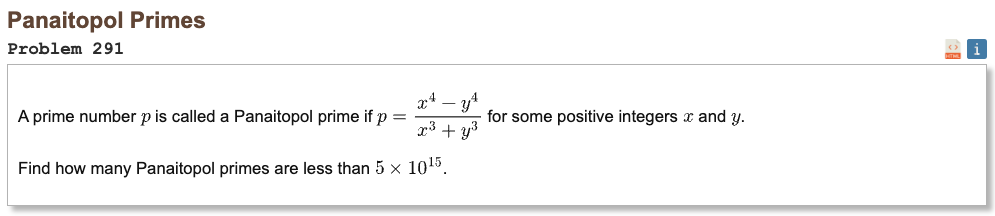

## Initial approach

* brute force over all pairs is unnecessary because the prime values collapse into one simple one-parameter family
* after simplifying the algebra, every valid prime comes from consecutive integers, so the search becomes checking one quadratic sequence
* the limit in this problem is less than five quadrillion, so the parameter only runs up to fifty million, which is large but still manageable with sieving
* instead of testing each value one by one, mark the parameter values that make the quadratic expression divisible by some prime
* only primes that leave remainder one when divided by four can divide this sequence, so about half the primes can be skipped immediately
* for each such prime, solve the two matching residue classes, then strike out every parameter value in those arithmetic progressions
* be careful not to strike out the rare case where the quadratic value is equal to the prime itself, because that one is actually prime
* the remaining unmarked values are exactly the Panaitopol primes

In [1]:
from math import isqrt

def odd_primes_upto(limit):
    if limit < 2:
        return []
    size = limit // 2 + 1
    sieve = bytearray(b"\x01") * size
    sieve[0] = 0
    root = isqrt(limit)
    for i in range(3, root + 1, 2):
        if sieve[i // 2]:
            start = i * i // 2
            step = i
            count = (size - start - 1) // step + 1
            sieve[start::step] = b"\x00" * count
    primes = [2]
    primes.extend(2 * i + 1 for i in range(1, size) if sieve[i])
    return primes

def count_panaitopol(limit):
    max_n = 0
    while 2 * max_n * max_n + 2 * max_n + 1 < limit:
        max_n += 1

    alive = bytearray(b"\x01") * max_n
    alive[0] = 0

    prime_limit = isqrt(limit)
    primes = odd_primes_upto(prime_limit)

    for p in primes:
        if p == 2 or p % 4 != 1:
            continue

        r = pow(p - 1, (p + 1) // 4, p)
        inv2 = (p + 1) // 2
        roots = {
            ((-1 + r) * inv2) % p,
            ((-1 - r) * inv2) % p
        }

        for start in roots:
            if start == 0:
                start += p
            if start >= max_n:
                continue

            value = 2 * start * start + 2 * start + 1
            if value == p:
                start += p
                if start >= max_n:
                    continue

            count = (max_n - start - 1) // p + 1
            alive[start::p] = b"\x00" * count

    return sum(alive)

In [2]:
%%time
result = count_panaitopol(5 * 10**15)
print("Result:", result)

Result: 2699391
CPU times: user 7.44 s, sys: 94.9 ms, total: 7.54 s
Wall time: 7.59 s
